# H-010 · Exits: ATR stop (+ breaker) then HL time-stop

Sequential freeze (no joint ATR×HL grid):

1. **Screen A** — ATR multiples {2, 2.5, 3} vs mean_only (HL off). ATR arms use Wilder-14 ATR stop at k×ATR, risk-targeted sizing (hit ≈ tr_risk_frac of book), and PAIR_MAX_LOSS breaker. Stop triggers on **spread close** at signal 	 (fill open 	+1); not intrabar H/L.
2. Freeze ATR_EXIT_STAR (+ PAIR_MAX_LOSS_STAR when ATR on).
3. **Screen B** — HL on/off (
=3 half-lives) with ATR frozen from A.
4. Freeze HL_EXIT_STAR. **Combine rule:** enable both only if each screen independently selected its non-baseline arm (manual review; no argmax).

Type orthogonal STARs: ATR_EXIT_STAR, HL_EXIT_STAR, PAIR_MAX_LOSS_STAR.


## 0. Imports & Config


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.report import (
    arm_selection_table,
    fold_table,
    fold_val_metrics,
    full_is_metrics,
    load_star_stack,
    median_sharpe_hint,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    load_s1_weekly,
    frozen_pairs_for_universe,
    load_universe_panels,
    lookbacks_for_bar,
    overlay_kalman_hedge,
    overlay_ols_hedge,
    n_trials_local,
    n_trials_stack,
    register_hypothesis_arms,
    repo_root,
    split_is_oos,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds
from strategies.s2_coint.config import S2SimConfig

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)
# Universe from H-001. PAIRS_STAR is only populated when BOOK_STAR = freeze (H-004);
# otherwise fall back to the ranked frozen book written by H-001.
require_star("UNIVERSE_STAR", stack.get("UNIVERSE_STAR"))
UNIVERSE = str(stack["UNIVERSE_STAR"])
PAIRS_STAR = list(stack.get("PAIRS_STAR") or frozen_pairs_for_universe(UNIVERSE, "1d", root=ROOT))
print("stack keys:", sorted(stack))
print("UNIVERSE", UNIVERSE, "PAIRS", PAIRS_STAR)


stack keys: ['ADF_WINDOW_STAR', 'ATR_EXIT_STAR', 'BAR_STAR', 'BOOK_STAR', 'BREAK_STAR', 'CORR_GATE_STAR', 'ENTRY_STAR', 'ENTRY_Z_STAR', 'HEDGE_STAR', 'HL_EXIT_STAR', 'HL_GATE_STAR', 'KALMAN_DELTA_STAR', 'OLS_WINDOW_STAR', 'OVERLAP_STAR', 'PAIRS_STAR', 'PAIR_MAX_LOSS_STAR', 'RESEARCH_IS_END_STAR', 'SIZE_STAR', 'TREND_STAR', 'UNIVERSE_STAR', 'VOL_STAR', 'VT_TARGET_ANN_VOL_STAR', 'VT_TARGET_PICK_STAR', 'VT_TARGET_SOURCE_STAR', 'VT_TARGET_WRITTEN_AT_STAR', 'Z_WINDOW_MODE_STAR', 'Z_WINDOW_STAR']
UNIVERSE D PAIRS ['WSO|WSO.B', 'HEI|HEI.A', 'NWS|NWSA']


### 0.1 H-010 exit constants (edit here)

`PAIR_MAX_LOSS` applies only on ATR-stop arms (catastrophe breaker). ATR multiples are screened in A; HL uses fixed `HL_EXIT_N` in B.


In [2]:
# --- H-010 editable constants ---
PAIR_MAX_LOSS = -0.10  # per-pair breaker when ATR stop is on
ATR_MULTS = (1.5, 2.0, 2.5)
HL_EXIT_N = 3.0  # half-lives for the HL-on arm in screen B
ATR_RISK_FRAC = 0.01  # book loss target at the k×ATR stop

HYP_ID = "H-010"
ALL_ARM_NAMES = (
    ["mean_only"]
    + [f"atr_{m:g}" for m in ATR_MULTS]
    + ["hl_off", "hl_on"]
)
register_hypothesis_arms(HYP_ID, ALL_ARM_NAMES, overwrite=True)
print("PAIR_MAX_LOSS", PAIR_MAX_LOSS, "ATR_MULTS", ATR_MULTS, "HL_EXIT_N", HL_EXIT_N)
print("ledger arms", ALL_ARM_NAMES)


PAIR_MAX_LOSS -0.1 ATR_MULTS (1.5, 2.0, 2.5) HL_EXIT_N 3.0
ledger arms ['mean_only', 'atr_1.5', 'atr_2', 'atr_2.5', 'hl_off', 'hl_on']


## 1. Load frozen panel / PAIRS_STAR


In [3]:
require_star("BAR_STAR", stack.get("BAR_STAR"))
BAR = str(stack["BAR_STAR"])
train, full = load_universe_panels(UNIVERSE, BAR, PAIRS_STAR, root=ROOT)
lb = lookbacks_for_bar(
    BAR,
    ols_days=int(stack["OLS_WINDOW_STAR"]) if stack.get("OLS_WINDOW_STAR") not in (None, "") else None,
    z_days=int(stack["Z_WINDOW_STAR"]) if stack.get("Z_WINDOW_STAR") not in (None, "") else None,
    adf_days=int(stack["ADF_WINDOW_STAR"]) if stack.get("ADF_WINDOW_STAR") not in (None, "") else None,
)
train = overlay_ols_hedge(
    train,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
full = overlay_ols_hedge(
    full,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
if stack.get("HEDGE_STAR") == "kalman":
    kf_delta = stack["KALMAN_DELTA_STAR"]
    train = overlay_kalman_hedge(
        train,
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=kf_delta,
    )
    full = overlay_kalman_hedge(
        full,
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=kf_delta,
    )

is_end = is_end_for_stack(stack, full if BAR == "1h" else train)
if BAR == "1d":
    is_panel, oos_panel = train.copy(), full.loc[pd.to_datetime(full["date"]) > is_end].copy()
else:
    is_panel, oos_panel = split_is_oos(full, is_end=is_end)
s1_weekly = load_s1_weekly(ROOT)
print("bar", BAR, "is_end", is_end, "IS rows", len(is_panel), "OOS rows", len(oos_panel))
is_panel.head()


bar 1d is_end 2021-12-31 00:00:00 IS rows 8113 OOS rows 2346


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,1998-04-27,HEI|HEI.A,HEI,HEI.A,4.726864,4.726864,4.608692,4.726864,4.648083,4.648083,4.569302,4.588997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1998-04-28,HEI|HEI.A,HEI,HEI.A,4.726864,4.785950,4.726864,4.785950,4.588997,4.588997,4.529911,4.569302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1998-04-29,HEI|HEI.A,HEI,HEI.A,4.785950,4.864731,4.785950,4.864731,4.549607,4.549607,4.510216,4.510216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1998-04-30,HEI|HEI.A,HEI,HEI.A,4.904121,4.982902,4.894274,4.982902,4.490521,4.510216,4.431435,4.451130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1998-05-01,HEI|HEI.A,HEI,HEI.A,4.923817,5.140465,4.923817,5.140465,4.411740,4.490521,4.411740,4.451130,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Attach this-hyp columns


In [4]:
panel = is_panel.copy()
# ATR / spread OHLC (incl. spread_close) attached by the runner when atr_stop_mult is set.
print(panel.columns.tolist())
panel.head()


['date', 'pair_id', 'ticker_y', 'ticker_x', 'open_y', 'high_y', 'low_y', 'close_y', 'open_x', 'high_x', 'low_x', 'close_x', 'alpha', 'beta', 'spread', 'z', 'half_life', 'adf_pvalue', 'variance_jump']


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,1998-04-27,HEI|HEI.A,HEI,HEI.A,4.726864,4.726864,4.608692,4.726864,4.648083,4.648083,4.569302,4.588997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1998-04-28,HEI|HEI.A,HEI,HEI.A,4.726864,4.785950,4.726864,4.785950,4.588997,4.588997,4.529911,4.569302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1998-04-29,HEI|HEI.A,HEI,HEI.A,4.785950,4.864731,4.785950,4.864731,4.549607,4.549607,4.510216,4.510216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1998-04-30,HEI|HEI.A,HEI,HEI.A,4.904121,4.982902,4.894274,4.982902,4.490521,4.510216,4.431435,4.451130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1998-05-01,HEI|HEI.A,HEI,HEI.A,4.923817,5.140465,4.923817,5.140465,4.411740,4.490521,4.411740,4.451130,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Walk-forward folds


In [5]:
dates = pd.DatetimeIndex(pd.to_datetime(panel["date"])).sort_values().unique()
folds = make_s2_folds(dates, n_folds=3, embargo_bars=embargo_bars_for_config(bar=BAR))
fold_table(folds)


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,1998-04-27,2004-03-22,1485,2004-03-23,2004-03-29,2004-03-30,2010-03-02,1491
1,2,1998-04-27,2010-02-23,2976,2010-02-24,2010-03-02,2010-03-03,2016-02-01,1490
2,3,1998-04-27,2016-01-25,4466,2016-01-26,2016-02-01,2016-02-02,2021-12-31,1491


## 4. Screen A — ATR multiples (HL off)

Arms: `mean_only` + `atr_{k}` for `k in ATR_MULTS`. No HL timeout. Breaker + risk-targeted ATR sizing only on ATR arms.


In [6]:
configs_atr = {
    "mean_only": config_from_stack(
        stack,
        atr_stop_mult=None,
        hl_exit_n=None,
    ),
}
for m in ATR_MULTS:
    configs_atr[f"atr_{m:g}"] = config_from_stack(
        stack,
        atr_stop_mult=float(m),
        hl_exit_n=None,
        pair_max_loss=float(PAIR_MAX_LOSS),
        atr_risk_frac=float(ATR_RISK_FRAC),
    )

fold_df_atr = fold_val_metrics(panel, folds, configs_atr, hyp_id=HYP_ID, s1_weekly=s1_weekly)
full_is_df_atr = full_is_metrics(panel, configs_atr, hyp_id=HYP_ID, s1_weekly=s1_weekly)
fold_df_atr


,arm,fold_id,ann_sharpe,max_drawdown,corr_to_s1,psr,dsr_local,dsr_stack,n_trials_local,n_trials_stack,n_days,n_entries,pct_z_finite,median_hl_bars,median_hl_sessions
0,mean_only,1,0.364753,-0.030159,NaN,0.0,1.0,1.0,4,32,1491,12,1.00000,11.086695,11.086695
1,mean_only,2,-0.207623,-0.045696,0.071104,0.0,0.0,0.0,4,32,1490,9,0.84186,12.978339,12.978339
2,mean_only,3,0.451952,-0.022136,0.207541,0.0,1.0,1.0,4,32,1491,36,1.00000,9.775787,9.775787
3,atr_1.5,1,0.364753,-0.030159,NaN,0.0,1.0,1.0,4,32,1491,12,1.00000,11.086695,11.086695
4,atr_1.5,2,-0.207623,-0.045696,0.071104,0.0,0.0,0.0,4,32,1490,9,0.84186,12.978339,12.978339
5,atr_1.5,3,0.451952,-0.022136,0.207541,0.0,1.0,1.0,4,32,1491,36,1.00000,9.775787,9.775787
6,atr_2,1,0.364753,-0.030159,NaN,0.0,1.0,1.0,4,32,1491,12,1.00000,11.086695,11.086695
7,atr_2,2,-0.207623,-0.045696,0.071104,0.0,0.0,0.0,4,32,1490,9,0.84186,12.978339,12.978339
8,atr_2,3,0.451952,-0.022136,0.207541,0.0,1.0,1.0,4,32,1491,36,1.00000,9.775787,9.775787
9,atr_2.5,1,0.364753,-0.030159,NaN,0.0,1.0,1.0,4,32,1491,12,1.00000,11.086695,11.086695


## 5. Boxplots A (do not assign STAR here)


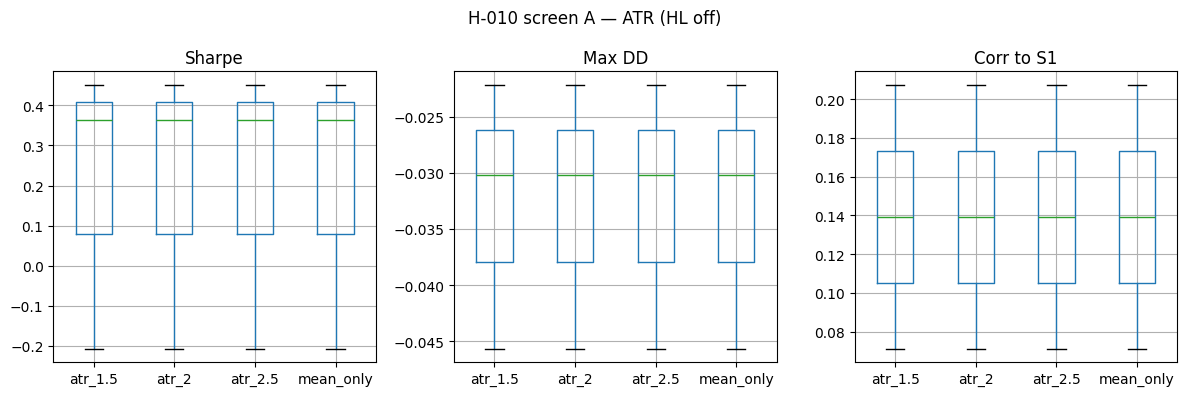

median-Sharpe hint (commentary only): atr_1.5


,arm,median_val_sharpe,full_is_sharpe,max_drawdown,corr_to_s1,n_folds,median_psr,median_dsr_local,median_dsr_stack,full_is_psr,full_is_dsr_local,full_is_dsr_stack
0,atr_1.5,0.364753,0.258107,-0.030159,0.139323,3,0.0,1.0,1.0,0.0,1.0,1.0
1,atr_2,0.364753,0.258107,-0.030159,0.139323,3,0.0,1.0,1.0,0.0,1.0,1.0
2,atr_2.5,0.364753,0.258107,-0.030159,0.139323,3,0.0,1.0,1.0,0.0,1.0,1.0
3,mean_only,0.364753,0.339690,-0.030159,0.139323,3,0.0,1.0,1.0,0.0,1.0,1.0


In [7]:
plot_fold_boxplots(fold_df_atr, title="H-010 screen A — ATR (HL off)")
plt.show()
print("median-Sharpe hint (commentary only):", median_sharpe_hint(fold_df_atr))
display(arm_selection_table(fold_df_atr, full_is_df_atr))


## 6. Freeze `ATR_EXIT_STAR`

Pre-registered: pick ATR only if an ATR arm beats `mean_only` on fold-val (Sharpe / max DD / corr to S1 — manual). Else `"off"`.
Do **not** use argmax / median Sharpe as an automatic selector.


In [8]:
ATR_EXIT_STAR = "off"  # TODO set after review — e.g. 2.0 / 2.5 / 3.0 / "off"
require_star("ATR_EXIT_STAR", ATR_EXIT_STAR)
stack["ATR_EXIT_STAR"] = ATR_EXIT_STAR
stack.pop("EXIT_STAR", None)  # drop legacy composite key
if ATR_EXIT_STAR not in (None, "off"):
    stack["PAIR_MAX_LOSS_STAR"] = float(PAIR_MAX_LOSS)
    require_star("PAIR_MAX_LOSS_STAR", stack["PAIR_MAX_LOSS_STAR"])
save_star_stack(STAR_PATH, stack)
print("ATR_EXIT_STAR", ATR_EXIT_STAR, "PAIR_MAX_LOSS_STAR", stack.get("PAIR_MAX_LOSS_STAR"))


ATR_EXIT_STAR off PAIR_MAX_LOSS_STAR -0.1


## 7. Screen B — HL on/off (ATR frozen)

With `ATR_EXIT_STAR` frozen from §6, compare `hl_off` vs `hl_on` (`HL_EXIT_N` half-lives). Breaker remains only if ATR is on.


In [9]:
stack = load_star_stack(STAR_PATH)
atr_frozen = None if stack.get("ATR_EXIT_STAR") in (None, "off") else float(stack["ATR_EXIT_STAR"])
pair_loss = float(stack.get("PAIR_MAX_LOSS_STAR", PAIR_MAX_LOSS))

configs_hl = {
    "hl_off": config_from_stack(
        stack,
        atr_stop_mult=atr_frozen,
        hl_exit_n=None,
        pair_max_loss=pair_loss,
        atr_risk_frac=float(ATR_RISK_FRAC),
    ),
    "hl_on": config_from_stack(
        stack,
        atr_stop_mult=atr_frozen,
        hl_exit_n=float(HL_EXIT_N),
        pair_max_loss=pair_loss,
        atr_risk_frac=float(ATR_RISK_FRAC),
    ),
}

fold_df_hl = fold_val_metrics(panel, folds, configs_hl, hyp_id=HYP_ID, s1_weekly=s1_weekly)
full_is_df_hl = full_is_metrics(panel, configs_hl, hyp_id=HYP_ID, s1_weekly=s1_weekly)
print("ATR frozen", atr_frozen)
fold_df_hl


ATR frozen None


,arm,fold_id,ann_sharpe,max_drawdown,corr_to_s1,psr,dsr_local,dsr_stack,n_trials_local,n_trials_stack,n_days,n_entries,pct_z_finite,median_hl_bars,median_hl_sessions
0,hl_off,1,0.364753,-0.030159,NaN,0.0,1.000000e+00,1.0,2,30,1491,12,1.00000,11.086695,11.086695
1,hl_off,2,-0.207623,-0.045696,0.071104,0.0,2.386980e-15,0.0,2,30,1490,9,0.84186,12.978339,12.978339
2,hl_off,3,0.451952,-0.022136,0.207541,0.0,1.000000e+00,1.0,2,30,1491,36,1.00000,9.775787,9.775787
3,hl_on,1,0.385260,-0.027416,NaN,0.0,1.000000e+00,1.0,2,30,1491,14,1.00000,11.086695,11.086695
4,hl_on,2,-0.282763,-0.038734,0.129553,0.0,0.000000e+00,0.0,2,30,1490,13,0.84186,12.978339,12.978339
5,hl_on,3,0.351382,-0.027747,0.208923,0.0,1.000000e+00,1.0,2,30,1491,44,1.00000,9.775787,9.775787


## 8. Boxplots B (do not assign STAR here)


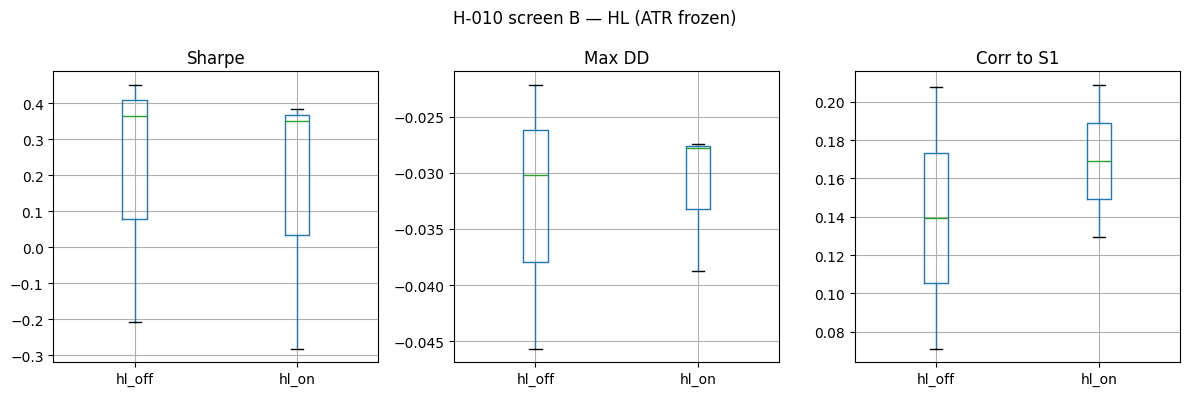

median-Sharpe hint (commentary only): hl_off


,arm,median_val_sharpe,full_is_sharpe,max_drawdown,corr_to_s1,n_folds,median_psr,median_dsr_local,median_dsr_stack,full_is_psr,full_is_dsr_local,full_is_dsr_stack
0,hl_off,0.364753,0.339690,-0.030159,0.139323,3,0.0,1.0,1.0,0.0,1.0,1.0
1,hl_on,0.351382,0.281986,-0.027747,0.169238,3,0.0,1.0,1.0,0.0,1.0,1.0


In [10]:
plot_fold_boxplots(fold_df_hl, title="H-010 screen B — HL (ATR frozen)")
plt.show()
print("median-Sharpe hint (commentary only):", median_sharpe_hint(fold_df_hl))
display(arm_selection_table(fold_df_hl, full_is_df_hl))


## 9. Freeze `HL_EXIT_STAR` (combine rule)

**Combine rule (pre-registered):** set `HL_EXIT_STAR="on"` only if HL-on beats HL-off on fold-val under the frozen ATR. Do not re-open the ATR grid. Both knobs may be on only when each screen independently selected its protective arm.


In [11]:
HL_EXIT_STAR = "off"  # TODO set after review — "on" or "off"
require_star("HL_EXIT_STAR", HL_EXIT_STAR)
stack["HL_EXIT_STAR"] = HL_EXIT_STAR
save_star_stack(STAR_PATH, stack)
print(
    "ATR_EXIT_STAR", stack.get("ATR_EXIT_STAR"),
    "HL_EXIT_STAR", HL_EXIT_STAR,
    "PAIR_MAX_LOSS_STAR", stack.get("PAIR_MAX_LOSS_STAR"),
)


ATR_EXIT_STAR off HL_EXIT_STAR off PAIR_MAX_LOSS_STAR -0.1


## 10. Sealed OOS once


In [12]:
require_star("ATR_EXIT_STAR", stack.get("ATR_EXIT_STAR"))
require_star("HL_EXIT_STAR", stack.get("HL_EXIT_STAR"))
oos_cfg = config_from_stack(load_star_stack(STAR_PATH))
# Local N = full H-010 arm set (both screens); not a single-screen subset.
n_loc = len(ALL_ARM_NAMES)
n_stk = n_trials_stack(HYP_ID, {k: None for k in ALL_ARM_NAMES})
oos = run_s2_backtest(
    oos_panel,
    oos_cfg,
    s1_weekly=s1_weekly,
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)

print(oos.metrics)
tag = f"atr_{stack.get('ATR_EXIT_STAR')}_hl_{stack.get('HL_EXIT_STAR')}"
write_tearsheet_pdf(
    tearsheet_path("H-010", tag),
    oos.returns,
    title="H-010 sealed OOS",
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)
print("tearsheet", tearsheet_path("H-010", tag))
print("oos cfg atr_stop_mult", oos_cfg.atr_stop_mult, "hl_exit_n", oos_cfg.hl_exit_n)


{'ann_sharpe': -0.25213990036606665, 'max_drawdown': -0.053201872972480024, 'n_days': 1173, 'psr': 0.0, 'dsr_local': 0.0, 'dsr_stack': 0.0, 'skew': -1.5104325234708544, 'excess_kurtosis': 40.74658701405078, 'n_trials_local': 6, 'n_trials_stack': 34, 'corr_to_s1': -0.025696774144739917}
tearsheet C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\H-010_atr_off_hl_off.pdf
oos cfg atr_stop_mult None hl_exit_n None


## 11. Notes for next hyp

H-011 Kalman spread-correlation gate is next (`off` | `0.50` | `0.70`).
